# ****Plant Disease Prediction****

## ****Importing libraries**** 

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## ****Data Preprocessing****

### ****Training Image preprocessing****   

In [2]:
training_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


### ****Validation Image Preprocessing****  

In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


####  ****To avoid Overshooting Loss function****
1. Choose small learning rate default 0.001 here we have taken 0.0001
2. There may be chance of underfitting so increase number of neuron
3. Add more Convolutional Layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or      model is confusing due to lack of feature so feed with more feature

In [4]:
training_set

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

###  ****

In [5]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[109.75 104.75 126.75]
   [130.75 125.75 147.75]
   [110.5  105.5  127.5 ]
   ...
   [ 93.75  88.75 108.75]
   [ 84.    79.    99.  ]
   [ 93.25  88.25 108.25]]

  [[111.25 106.25 128.25]
   [126.75 121.75 143.75]
   [ 95.25  90.25 112.25]
   ...
   [100.75  95.75 115.75]
   [ 91.    86.   106.  ]
   [ 97.75  92.75 112.75]]

  [[ 92.    87.   109.  ]
   [102.25  97.25 119.25]
   [101.75  96.75 118.75]
   ...
   [ 91.75  86.75 106.75]
   [ 84.5   79.5   99.5 ]
   [ 93.5   88.5  108.5 ]]

  ...

  [[179.25 181.25 202.25]
   [179.5  181.5  202.5 ]
   [158.5  160.5  181.5 ]
   ...
   [152.25 153.25 173.25]
   [147.   148.   168.  ]
   [147.   148.   168.  ]]

  [[167.25 169.25 190.25]
   [171.75 173.75 194.75]
   [164.5  166.5  187.5 ]
   ...
   [151.   152.   172.  ]
   [140.25 141.25 161.25]
   [142.5  143.5  163.5 ]]

  [[178.25 180.25 201.25]
   [160.75 162.75 183.75]
   [161.5  163.5  184.5 ]
   ...
   [140.75 141.75 161.75]
   [136.5  137.5  157.5 ]
   [140.   141.   16

## ****Building Model****

In [6]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

###  ****Building Convolution Layer****

In [7]:
model = Sequential()

In [8]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

/opt/conda/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [10]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [11]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [12]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [13]:
model.add(Dropout(0.25))

In [14]:
model.add(Flatten())

In [15]:
model.add(Dense(units=1500,activation='relu'))

In [16]:
model.add(Dropout(0.4)) #To avoid overfitting

In [17]:
model.add(Dense(units=38,activation='softmax'))

### ****Compiling and Training Phase**** 

In [18]:
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 126, 126, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 14, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1500)           │     3,073,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1500)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        57,038 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,842,762 (29.92 MB)

 Trainable params: 7,842,762 (29.92 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10


I0000 00:00:1731357478.954964      76 service.cc:145] XLA service 0x7ea130015bf0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731357478.955029      76 service.cc:153]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1731357478.955036      76 service.cc:153]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


   2/2197 ━━━━━━━━━━━━━━━━━━━━ 2:42 74ms/step - accuracy: 0.0000e+00 - loss: 6.2298  

I0000 00:00:1731357491.007406      76 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 154s 63ms/step - accuracy: 0.3731 - loss: 2.2566 - val_accuracy: 0.8323 - val_loss: 0.5501
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 112s 51ms/step - accuracy: 0.8303 - loss: 0.5373 - val_accuracy: 0.8965 - val_loss: 0.3433
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 112s 51ms/step - accuracy: 0.9011 - loss: 0.3087 - val_accuracy: 0.8961 - val_loss: 0.3214
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 112s 51ms/step - accuracy: 0.9321 - loss: 0.2069 - val_accuracy: 0.9349 - val_loss: 0.1978
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 112s 51ms/step - accuracy: 0.9508 - loss: 0.1493 - val_accuracy: 0.9544 - val_loss: 0.1435
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 112s 51ms/step - accuracy: 0.9617 - loss: 0.1144 - val_accuracy: 0.9150 - val_loss: 0.2982
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 122s 56ms/step - accuracy: 0.9712 - loss: 0.0906 - val_accuracy: 0.9555 - val_loss: 0.1405
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 124s 56ms/step - accuracy: 0.9738 - lo

## ****Evaluating Model**** 

In [21]:
#Training set Accuracy
train_loss, train_acc = model.evaluate(training_set)

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 33s 15ms/step - accuracy: 0.9715 - loss: 0.0901


In [22]:
print(train_loss, train_acc)

0.08473627269268036 0.9737534523010254


In [23]:
#Validation set Accuracy
val_loss, val_acc = model.evaluate(validation_set)

550/550 ━━━━━━━━━━━━━━━━━━━━ 8s 15ms/step - accuracy: 0.9422 - loss: 0.1995


In [24]:
print(val_loss, val_acc)

0.19403117895126343 0.9430343508720398


### ****Saving Model****  

In [25]:
model.save("trained_model.keras")

In [26]:
training_history.history #Return Dictionary of history

{'accuracy': [0.5789458751678467,
  0.8539725542068481,
  0.9111316800117493,
  0.9374920129776001,
  0.953311026096344,
  0.9641510844230652,
  0.972288191318512,
  0.9751617908477783,
  0.9792730808258057,
  0.9810085892677307],
 'loss': [1.4422155618667603,
  0.4624807834625244,
  0.27568089962005615,
  0.19118104875087738,
  0.14230994880199432,
  0.10699523240327835,
  0.0867890864610672,
  0.07779250293970108,
  0.06349285691976547,
  0.05963130667805672],
 'val_accuracy': [0.83228999376297,
  0.8965399265289307,
  0.8961415886878967,
  0.9348964095115662,
  0.954359233379364,
  0.9149783849716187,
  0.9554973840713501,
  0.9559526443481445,
  0.9647734761238098,
  0.9430343508720398],
 'val_loss': [0.5501271486282349,
  0.34330835938453674,
  0.32141101360321045,
  0.1977916657924652,
  0.14348289370536804,
  0.29824164509773254,
  0.14046692848205566,
  0.14755477011203766,
  0.11985074728727341,
  0.1940312534570694]}

In [27]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [28]:
print(training_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


## ****Accuracy Visualization****

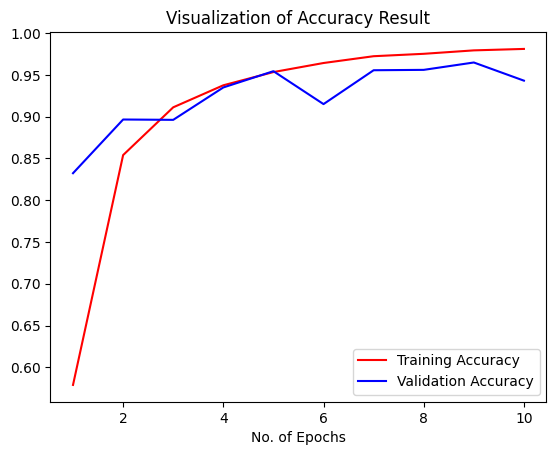

In [29]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

## ****Some other metrics for model evaluation****

In [30]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [31]:
test_set = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [32]:
y_pred = model.predict(test_set)
y_pred,y_pred.shape 

17572/17572 ━━━━━━━━━━━━━━━━━━━━ 34s 2ms/step


(array([[9.99996066e-01, 8.35961771e-08, 6.56540045e-10, ...,
         2.77026449e-13, 3.01669158e-14, 3.32187403e-11],
        [9.99999881e-01, 7.97769240e-10, 2.32245473e-11, ...,
         7.57071484e-16, 5.01299350e-16, 9.72660131e-14],
        [1.00000000e+00, 1.52235752e-10, 8.30237060e-11, ...,
         4.95120123e-19, 1.20359918e-18, 2.73314303e-13],
        ...,
        [2.54714028e-10, 3.00629442e-14, 7.29932503e-10, ...,
         1.59183419e-12, 3.78533955e-13, 9.99999762e-01],
        [8.32877944e-08, 7.88663093e-11, 1.03415381e-07, ...,
         1.11737564e-09, 3.88917676e-10, 9.99996781e-01],
        [1.40412202e-16, 1.30032495e-17, 1.04814694e-15, ...,
         3.82364264e-19, 3.04359651e-17, 1.00000000e+00]], dtype=float32),
 (17572, 38))

In [33]:
predicted_categories = tf.argmax(y_pred, axis=1)
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [34]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [35]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37])>

In [36]:
from sklearn.metrics import classification_report,confusion_matrix

In [37]:
# Precision Recall Fscore
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.89      0.94      0.91       504
                                 Apple___Black_rot       0.96      0.98      0.97       497
                          Apple___Cedar_apple_rust       0.92      0.98      0.95       440
                                   Apple___healthy       0.94      0.93      0.93       502
                               Blueberry___healthy       0.99      0.91      0.95       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.87      0.93       421
                 Cherry_(including_sour)___healthy       0.96      0.99      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.84      0.91      0.87       410
                       Corn_(maize)___Common_rust_       0.93      1.00      0.96       477
               Corn_(maize)___Northern_Leaf_Blight       0.85      0.94      0.

### ****Confusion Matrix Visualization**** 

In [38]:
cm = confusion_matrix(Y_true,predicted_categories)
cm

array([[474,   5,   1, ...,   0,   0,   0],
       [  1, 489,   0, ...,   0,   0,   0],
       [  0,   0, 431, ...,   0,   0,   1],
       ...,
       [  0,   0,   0, ..., 487,   0,   0],
       [  0,   0,   0, ...,   0, 437,   0],
       [  5,   0,   0, ...,   0,   0, 468]])

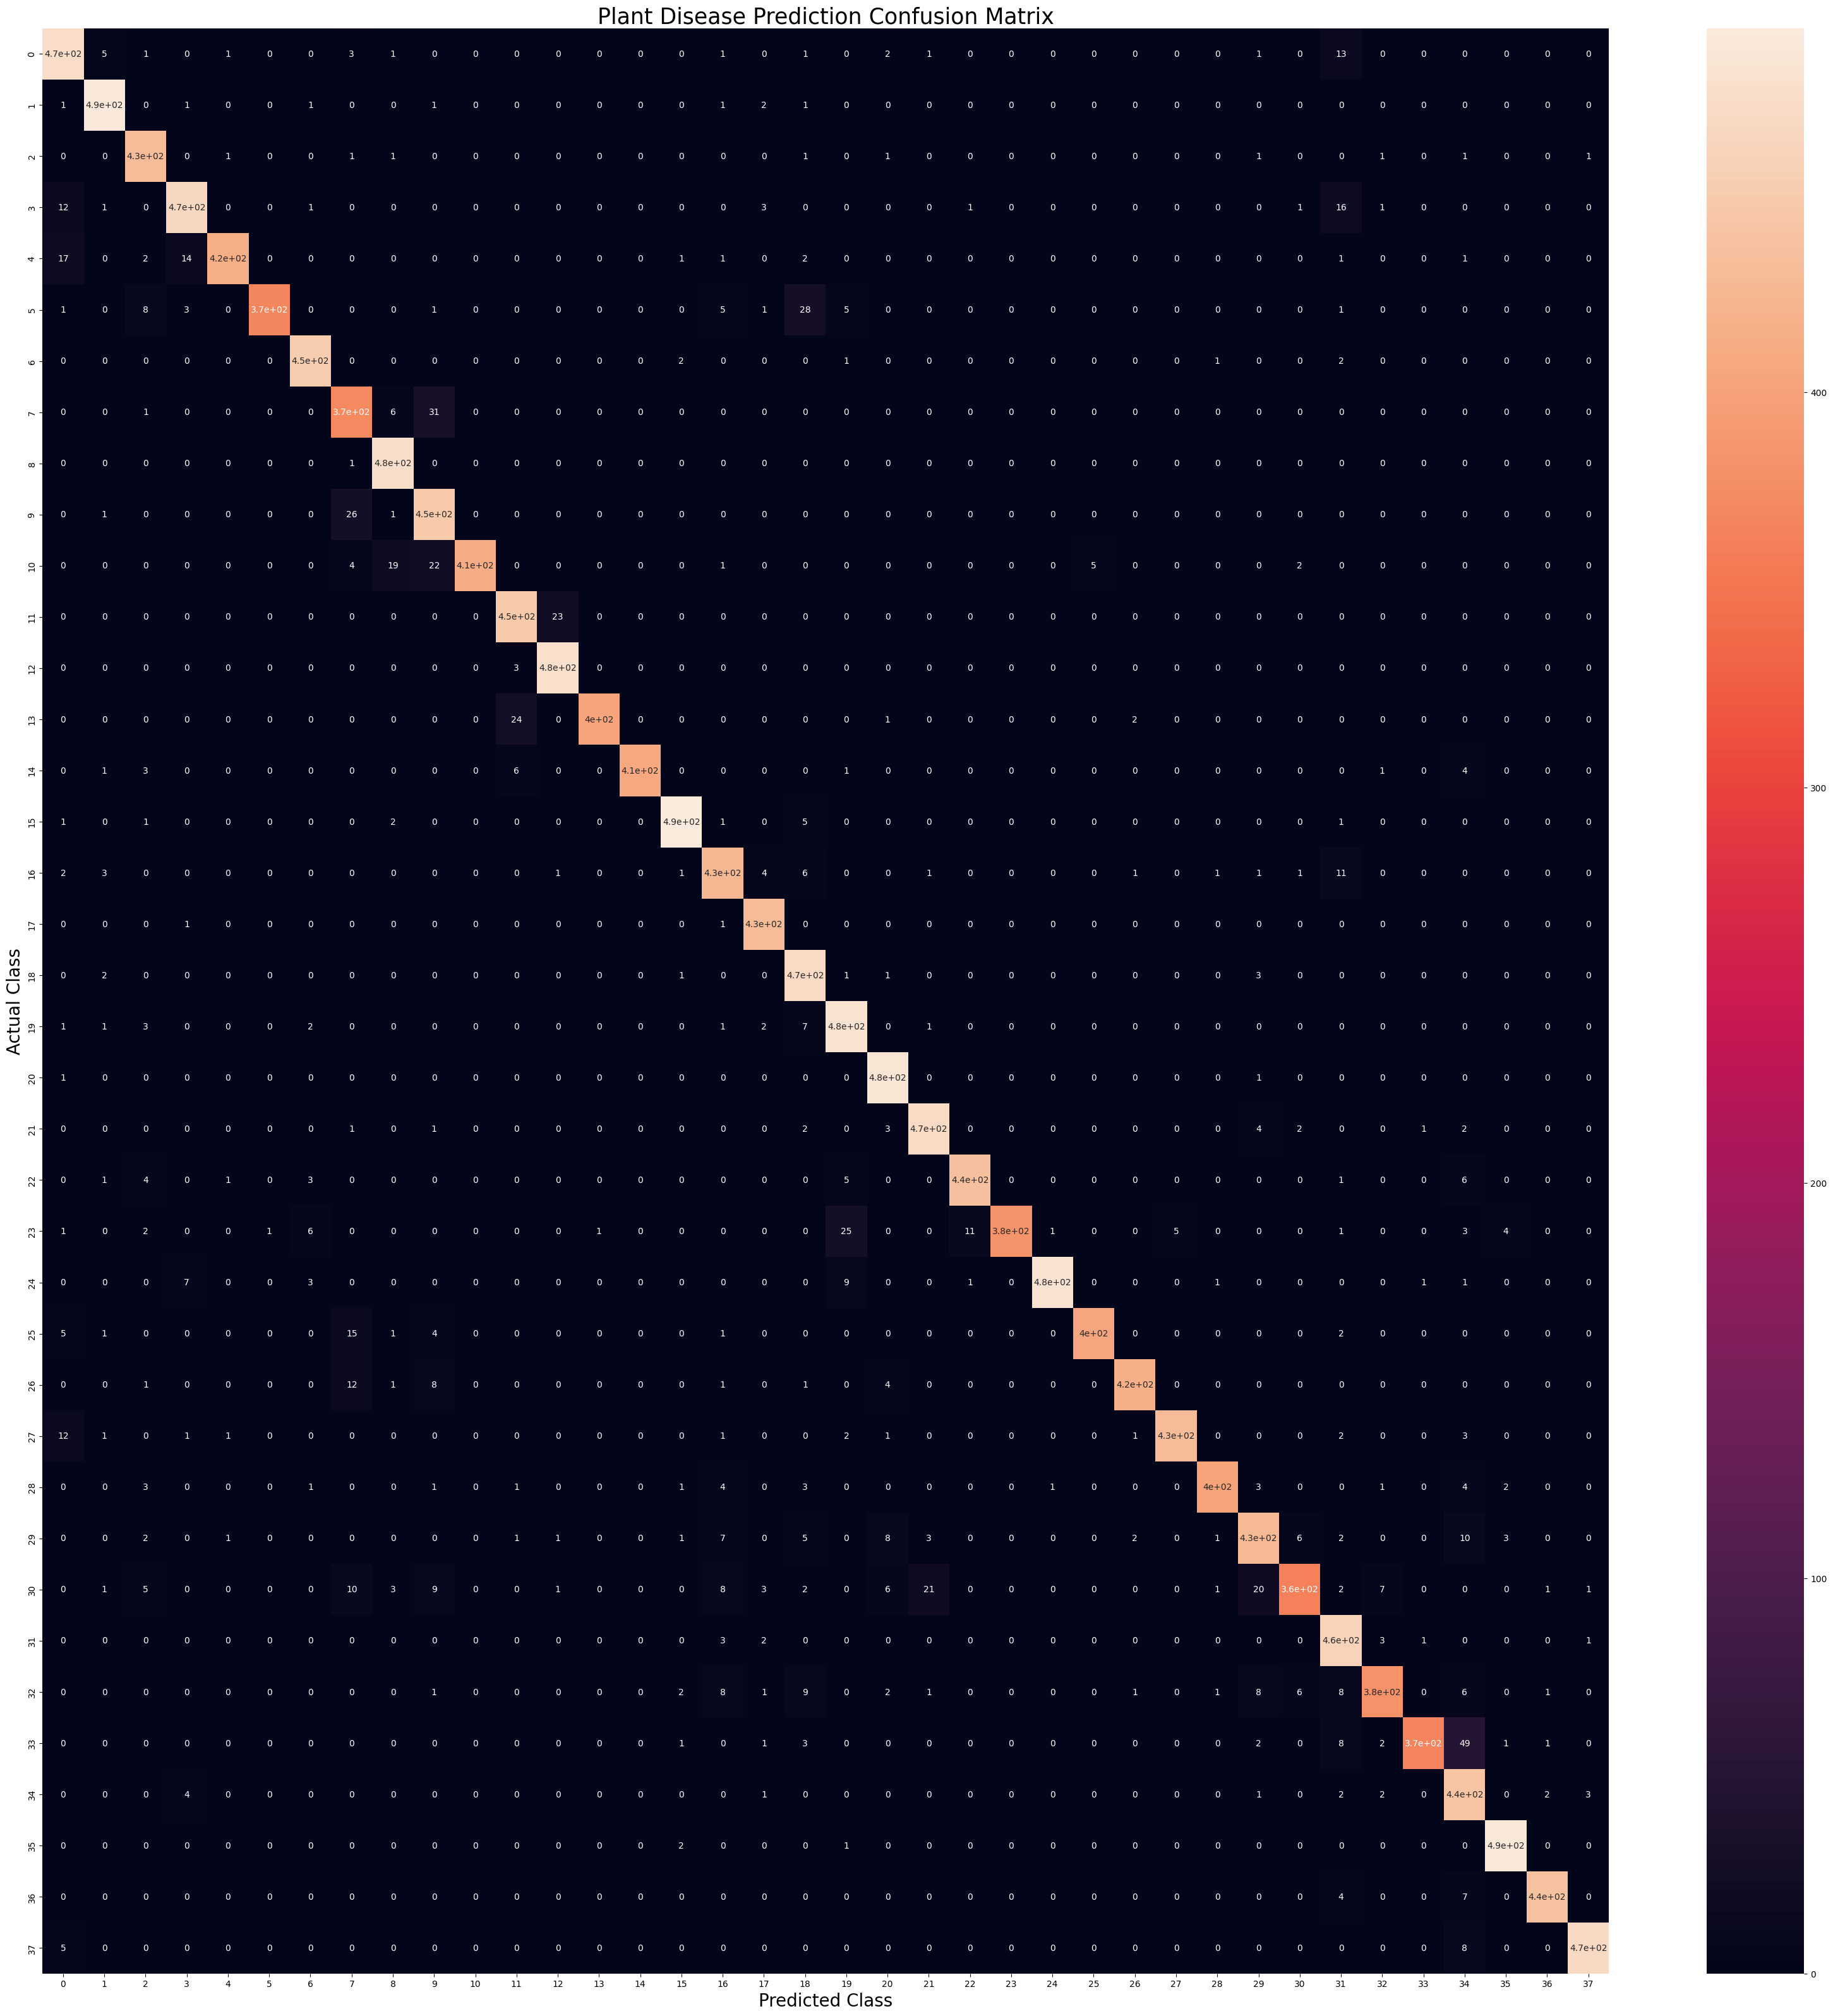

In [39]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()